<a href="https://colab.research.google.com/github/Priyankabhadu1/vendor_performance_analysis/blob/main/Vendor_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import os
import sqlite3
from sqlalchemy import create_engine

In [3]:
engine = create_engine('sqlite:///inventory.db' )

In [ ]:
def ingest_db(df, table_name, engine):
    df.to_sql(
        table_name,
        con=engine,
        if_exists='replace',
        index=False,
        chunksize=10000,      # insert 10k rows at a time
        method='multi'        # bulk insert
    )

path = '/content/data'

for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(path, file))
        print(file, df.shape)
        ingest_db(df, file[:-4], engine)

**Exploratory data analysis**

understanding the data to explore how the data is present in the database

In [4]:
# creating database connection
conn = sqlite3.connect('inventory.db')
# checking tables present in the database
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables

,name
0,begin_inventory
1,sales
2,vendor_invoice
3,purchases
4,purchase_prices
5,end_inventory


In [5]:
for table in tables ['name']:
  print('-'*50, f'{table}','-'*50)
  print( 'Count of records:', pd. read_sql(f"select count(*) as count from {table}", conn)['count']. values [0])
  display(pd.read_sql(f"select * from {table} limit 5", conn) )

-------------------------------------------------- begin_inventory --------------------------------------------------
Count of records: 206529


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


-------------------------------------------------- sales --------------------------------------------------
Count of records: 12825363


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY


-------------------------------------------------- vendor_invoice --------------------------------------------------
Count of records: 5543


...

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


-------------------------------------------------- purchase_prices --------------------------------------------------
Count of records: 12261


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


-------------------------------------------------- end_inventory --------------------------------------------------
Count of records: 30000


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [6]:
purchases = pd.read_sql('SELECT * FROM purchases', conn)
purchases.groupby(['Brand','PurchasePrice'])[['Quantity', 'Dollars']].sum()

,,Quantity,Dollars
Brand,PurchasePrice,,
58,9.28,3550,32944.00
60,7.40,1633,12084.20
61,10.60,312,3307.20
62,28.67,3200,91744.00
63,30.46,2855,86963.30
...,...,...,...
90089,77.92,32,2493.44
90090,448.27,6,2689.62
90604,78.42,118,9253.56


In [7]:
purchase_prices_df = pd.read_sql('SELECT * FROM purchase_prices', conn)
purchase_prices_df

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.
...,...,...,...,...,...,...,...,...,...
12256,44917,Ferreira 10-Yr Tawny Port,24.99,750mL,750,2,16.55,90024,VINILANDIA USA
12257,44944,Sanford Santa Rita Pnt Nr,22.99,750mL,750,2,14.93,4425,MARTIGNETTI COMPANIES
12258,45016,Neal One Lane Bridg Cab Svgn,93.99,750mL,750,2,61.43,10754,PERFECTA WINES
12259,46011,Folonari Pnt Nr Venezie,12.99,1500ml,1500,2,8.90,9744,FREDERICK WILDMAN & SONS


In [8]:
vendor_invoice = pd.read_sql('SELECT * FROM vendor_invoice', conn)
vendor_invoice['PONumber'].nunique()

5543

In [9]:
query = """
SELECT
    Brand,
    SUM(SalesDollars) AS SalesDollars,
    SUM(SalesPrice) AS SalesPrice,
    SUM(SalesQuantity) AS SalesQuantity
FROM sales
GROUP BY Brand
"""

sales_summary = pd.read_sql(query, conn)
display(sales_summary)

,Brand,SalesDollars,SalesPrice,SalesQuantity
0,58,43341.54,28145.64,3446
1,60,18716.25,10720.79,1775
2,61,4364.88,363.74,312
3,62,119863.75,90154.51,3125
4,63,112249.22,88553.10,2778
...,...,...,...,...
11232,90089,19078.41,5759.52,159
11233,90090,9749.85,4549.93,15
11234,90604,9119.24,2639.78,76
11235,90609,2074.17,1774.29,83


In [10]:
freight_summary = pd. read_sql_query("""select VendorNumber, SUM(Freight) as FreightCost
From vendor_invoice
Group BY VendorNumber""",conn)
freight_summary

,VendorNumber,FreightCost
0,2,27.08
1,54,0.48
2,60,367.52
3,105,62.39
4,200,6.19
...,...,...
121,98450,856.02
122,99166,130.09
123,172662,178.34
124,173357,202.50


In [11]:
pd. read_sql_query ("""SELECT
p.VendorNumber,
p.VendorName,
p.Brand,
p.PurchasePrice,
pp.Volume,
pp.Price as ActualPrice,
SUM(p.Quantity) as TotalPurchaseQuantity,
SUM(p.Dollars) as TotalPurchaseDollars
FROM purchases p
JOIN purchase_prices pp
ON p.Brand = pp.Brand
where p.PurchasePrice > 0
GROUP BY p.VendorNumber, p.VendorName, p.Brand
ORDER BY TotalPurchaseDollars""", conn)

,VendorNumber,VendorName,Brand,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars
0,7245,PROXIMO SPIRITS INC.,3065,0.71,50,0.99,1,0.71
1,3960,DIAGEO NORTH AMERICA INC,6127,1.47,200,1.99,1,1.47
2,3924,HEAVEN HILL DISTILLERIES,9123,0.74,50,0.99,2,1.48
3,8004,SAZERAC CO INC,5683,0.39,50,0.49,6,2.34
4,9815,WINE GROUP INC,8527,1.32,750,4.99,2,2.64
...,...,...,...,...,...,...,...,...
10687,3960,DIAGEO NORTH AMERICA INC,3545,21.89,1750,29.99,138109,3023206.01
10688,3960,DIAGEO NORTH AMERICA INC,4261,16.17,1750,22.99,201682,3261197.94
10689,17035,PERNOD RICARD USA,8068,18.24,1750,24.99,187407,3418303.68
10690,4425,MARTIGNETTI COMPANIES,3405,23.19,1750,28.99,164038,3804041.22


In [12]:
pd.read_sql_query("""SELECT
  VendorNo,
  Brand,
  SUM(SalesDollars) as TotalSalesDollars,
  SUM(SalesPrice) as TotalSalesPrice,
  SUM(SalesQuantity) as TotalSalesQuanity,
  SUM (ExciseTax) as TotalExciseTax
  FROM sales
  GROUP BY VendorNo, Brand
  ORDER BY TotalSalesDollars""", conn)

,VendorNo,Brand,TotalSalesDollars,TotalSalesPrice,TotalSalesQuanity,TotalExciseTax
0,8004,5287,9.800000e-01,0.98,2,0.10
1,9206,2773,9.900000e-01,0.99,1,0.05
2,3252,3933,1.980000e+00,0.99,2,0.10
3,3924,9123,1.980000e+00,0.99,2,0.10
4,10050,3623,1.980000e+00,1.98,2,0.10
...,...,...,...,...,...,...
11267,3960,3545,4.223108e+06,545778.28,135838,249587.83
11268,3960,4261,4.475973e+06,420050.01,200412,368242.80
11269,17035,8068,4.538121e+06,461140.15,187140,343854.07
11270,4425,3405,4.819073e+06,561512.37,160247,294438.66


In [13]:
import pandas as pd
vendor_sales_summary = pd.read_sql_query("""WITH FreightSummary AS (
  SELECT
    VendorNumber,
    SUM(Freight) AS FreightCost
  FROM vendor_invoice
  GROUP BY VendorNumber
),

PurchaseSummary AS (
  SELECT
    p.VendorNumber,
    p.VendorName,
    p.Brand,
    p.Description,
    p.PurchasePrice,
    pp.Price AS ActualPrice,
    pp.Volume,
    SUM(p.Quantity) AS TotalPurchaseQuantity,
    SUM(p.Dollars) AS TotalPurchaseDollars
FROM purchases p
JOIN purchase_prices pp
  ON p.Brand = pp.Brand
WHERE p.PurchasePrice > 0
GROUP BY p.VendorNumber, p.VendorName, p.Brand, p.Description, p.PurchasePrice, pp.Price, pp.Volume
),

SalesSummary AS (
  SELECT
    VendorNo,
    Brand,
    SUM (SalesQuantity) AS TotalSalesQuantity,
    SUM (SalesDollars) AS TotalSalesDollars,
    SUM(SalesPrice) AS TotalSalesPrice,
    SUM (ExciseTax) AS TotalExciseTax
  FROM sales
  GROUP BY VendorNo, Brand
)

SELECT
  ps.ActualPrice,
  ps.VendorNumber,
  ps.VendorName,
  ps.Brand,
  ps.Description,
  ps.PurchasePrice,
  ps.ActualPrice,
  ps.Volume,
  ps.TotalPurchaseQuantity,
  ps.TotalPurchaseDollars,
  ss.TotalSalesQuantity,
  ss.TotalSalesDollars,
  ss.TotalSalesPrice,
  ss.TotalExciseTax,
  fs.FreightCost
FROM PurchaseSummary ps
LEFT JOIN SalesSummary ss
  ON ps.VendorNumber = ss.VendorNo
  AND ps.Brand = ss.Brand
LEFT JOIN FreightSummary fs
  ON ps.VendorNumber = fs.VendorNumber
ORDER BY ps.TotalPurchaseDollars DESC""",conn)

In [14]:
vendor_sales_summary

,ActualPrice,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,36.99,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68
1,28.99,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24
2,24.99,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22
3,22.99,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07
4,29.99,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,4.99,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41
10688,0.49,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62
10689,0.99,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87
10690,1.99,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07


This query generates a vendor-wise sales and purchase summary, which is valuable for:

**Performance Optimization:**

• The query involves heavy joins and aggregations on large datasets like sales and purchases.

• Storing the pre-aggregated results avoids repeated expensive computations.

• Helps in analyzing sales, purchases, and pricing for different vendors and brands.

• Future Benefits of Storing this data for faster Dashboarding & Reporting.

• Instead of running expensive queries each time, dashboards can fetch data quickly from vendor.
sales _summary.


In [16]:
vendor_sales_summary.dtypes

,0
ActualPrice,float64
VendorNumber,int64
VendorName,object
Brand,int64
Description,object
PurchasePrice,float64
ActualPrice,float64
Volume,object
TotalPurchaseQuantity,int64
TotalPurchaseDollars,float64


In [17]:
vendor_sales_summary.isnull().sum()

,0
ActualPrice,0
VendorNumber,0
VendorName,0
Brand,0
Description,0
PurchasePrice,0
ActualPrice,0
Volume,0
TotalPurchaseQuantity,0
TotalPurchaseDollars,0


In [18]:
vendor_sales_summary['Volume'] = vendor_sales_summary['Volume'].astype('float64')

In [21]:
vendor_sales_summary.fillna(0, inplace=True)

In [23]:
vendor_sales_summary['VendorName']=vendor_sales_summary['VendorName'].str.strip()

In [24]:
vendor_sales_summary['GrossProfit'] = vendor_sales_summary['TotalSalesDollars'] - vendor_sales_summary['TotalPurchaseDollars']

In [25]:
vendor_sales_summary ['GrossProfit'].min()

-52002.78000000001

In [26]:
vendor_sales_summary ['ProfitMargin'] = (vendor_sales_summary['GrossProfit'] / vendor_sales_summary['TotalSalesDollars'])*100

In [27]:
vendor_sales_summary ['StockTurnover'] = vendor_sales_summary ['TotalSalesQuantity']/vendor_sales_summary['TotalPurchaseQuantity']

In [28]:
vendor_sales_summary ['SalestoPurchaseRatio'] = vendor_sales_summary['TotalSalesDollars']/vendor_sales_summary['TotalPurchaseDollars']

In [29]:
cursor = conn.cursor()

In [36]:
cursor.execute("""CREATE TABLE vendor_sales_summary (
VendorNumber INT,
VendorName VARCHAR(100),
Brand INT,
Description VARCHAR(100),
PurchasePrice DECIMAL (10,2),
ActualPrice DECIMAL (10,2),
Volume REAL,
TotalPurchaseQuantity INT,
TotalPurchaseDollars DECIMAL (15,2) ,
 TotalSalesQuantity REAL,
TotalSalesDollars DECIMAL(15,2),
TotalSalesPrice DECIMAL(15,2),
TotalExciseTax DECIMAL(15,2),
FreightCost DECIMAL (15,2),
GrossProfit DECIMAL (15,2),
ProfitMargin DECIMAL (15,2),
StockTurnover DECIMAL (15,2) ,
SalesToPurchaseRatio DECIMAL (15,2) ,
 PRIMARY KEY (VendorNumber, Brand)
);""")

In [39]:
vendor_sales_summary.to_sql('vendor_sales_summary', conn, if_exists = 'replace', index = False )

10692

In [40]:
pd.read_sql_query('SELECT * FROM vendor_sales_summary', conn)

,ActualPrice,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,36.99,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,28.99,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,24.99,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,22.99,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,29.99,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,4.99,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,0.49,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,0.99,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,1.99,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


**Data Analysis using python**

In [41]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3

from scipy.stats import ttest_ind
import scipy.stats as stats
warnings. filterwarnings('ignore')

In [42]:
# loading dataset
# creating database connection
conn = sqlite3. connect ('inventory.db' )
# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df. head ()

,ActualPrice,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,36.99,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,28.99,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,24.99,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,22.99,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,29.99,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


**Exploratory Data Analysis**


*   Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
*   In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [44]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


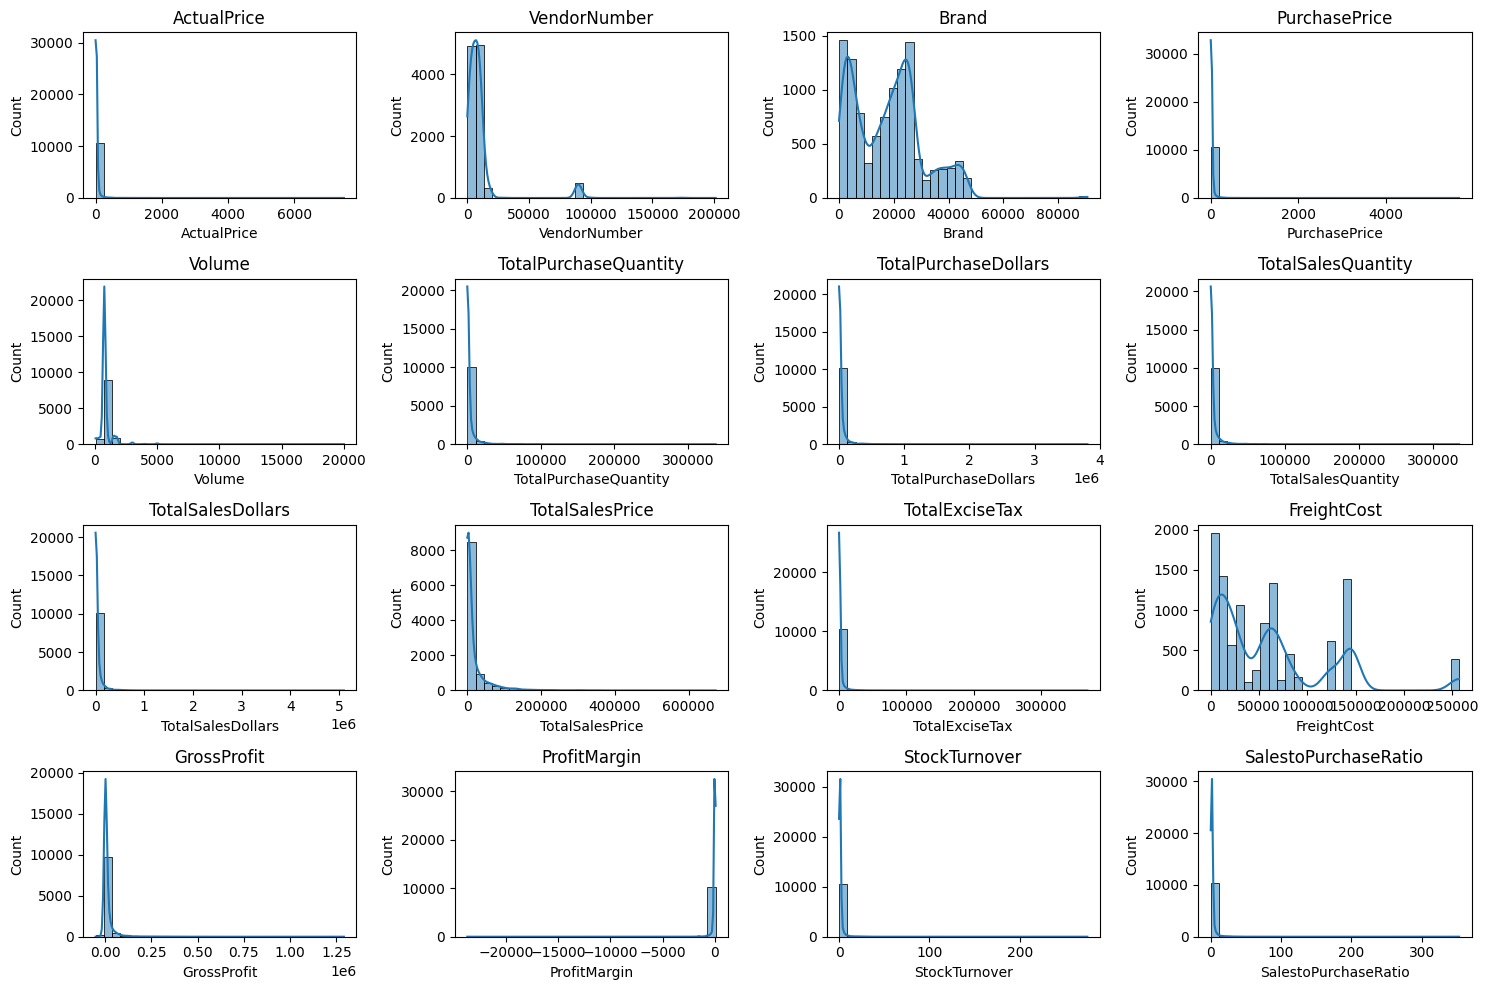

In [45]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
  plt.subplot(4, 4, i+1) # Adjust grid layout as needed
  sns.histplot(df[col], kde=True, bins=30)
  plt.title(col)
plt.tight_layout()
plt.show()

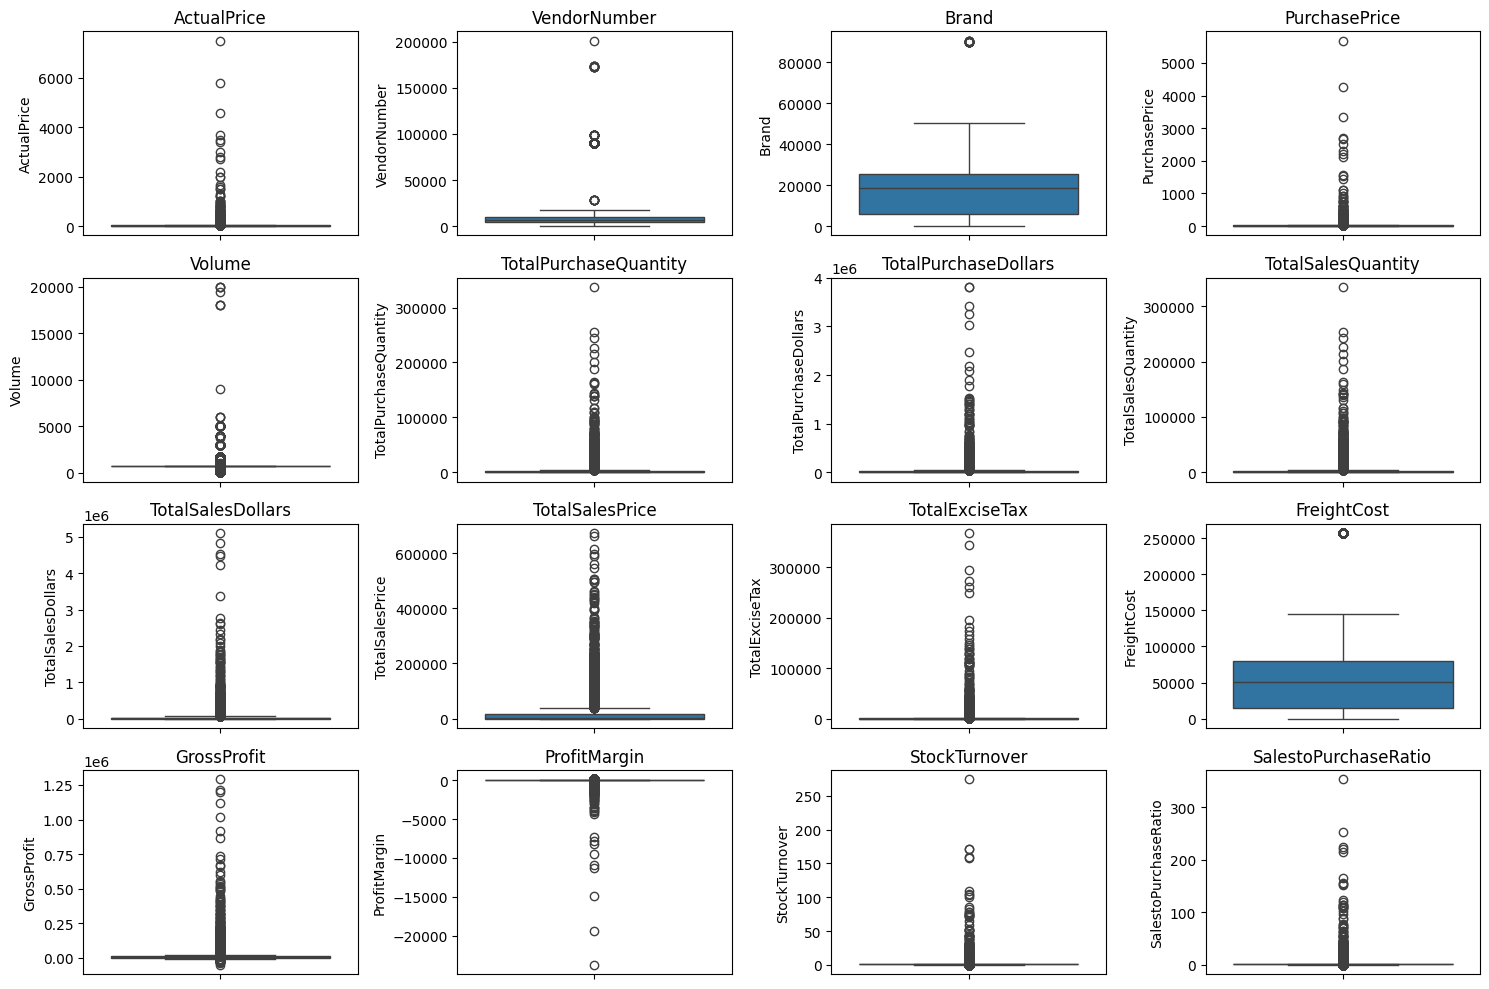

In [46]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate (numerical_cols):
  plt.subplot(4, 4, i+1)
  sns. boxplot (y=df [col])
  plt.title(col)
plt. tight_layout()
plt. show()

# Summary Statistics Insights:
**Negative & Zero Values:**
* Gross Profit: Minimum value is -52,002.78, indicating losses. Some
products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
* Profit Margin: Has a minimum of -o, which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**
* Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [47]:
# let's filter the data by removing inconsistencies
df = pd. read_sql_query ("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

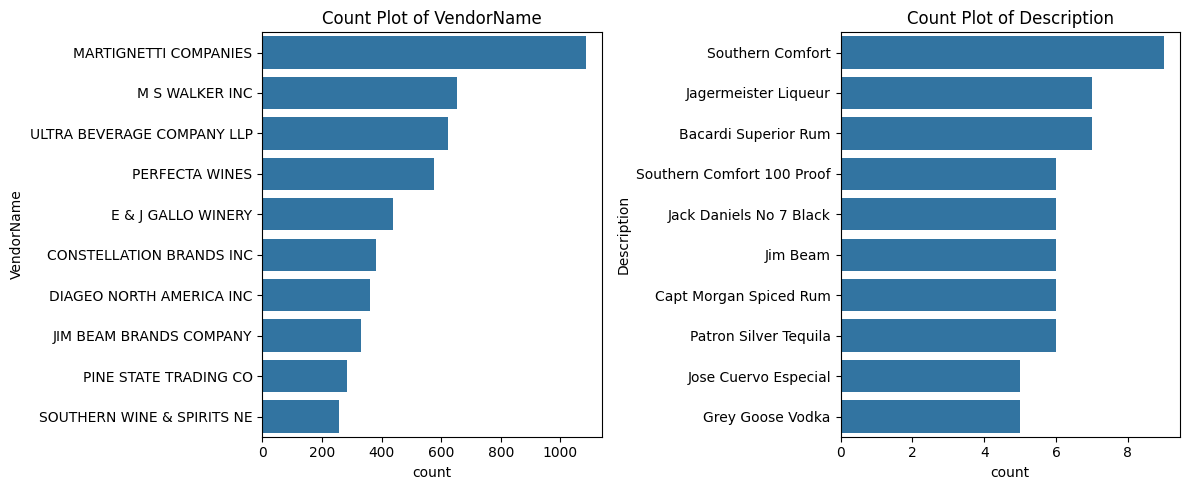

In [48]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate (categorical_cols):
  plt.subplot(1, 2, i+1)
  sns.countplot(y=df [col], order=df [col].value_counts().index[:10]) # Top 10 categories
  plt.title(f"Count Plot of {col}")
plt.tight_layout ()
plt. show()

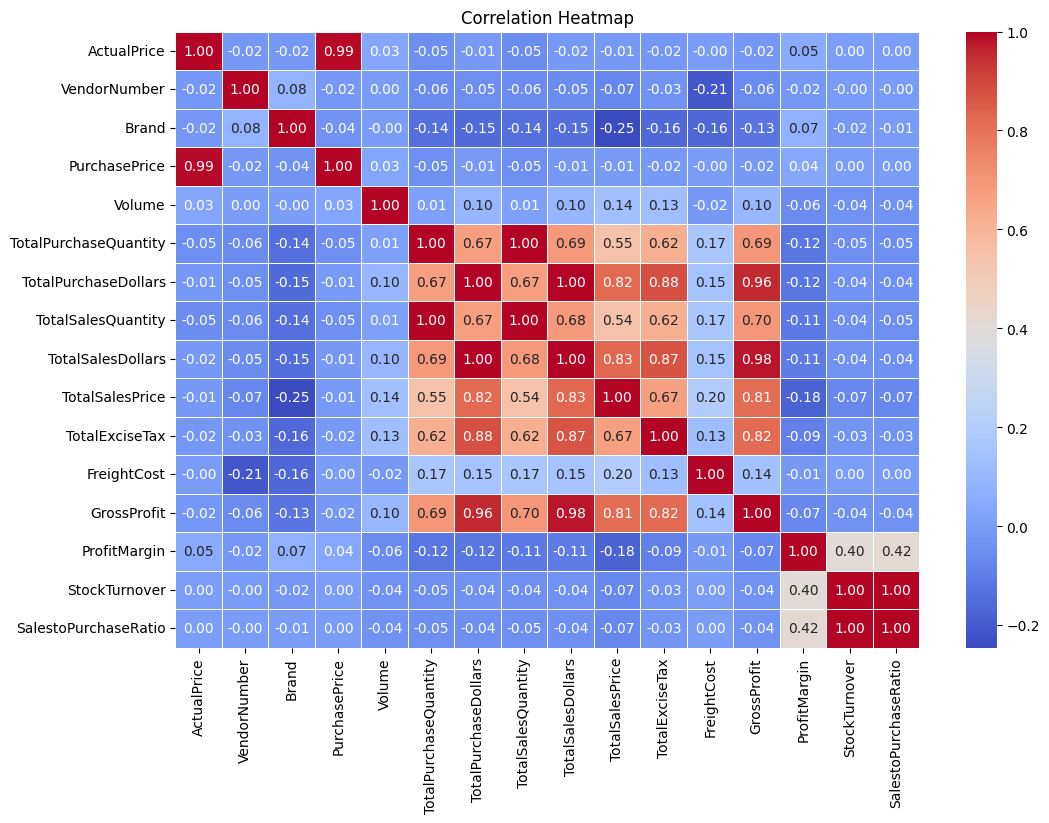

In [49]:
# Correlation Heatmap
plt. figure(figsize=(12, 8))
correlation_matrix = df [numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt. title("Correlation Heatmap")
plt. show()

## Data Analysis

**Identify brands that needs Promotional or pricing adjustments which exbihit lower sales performance but higher margins.**

In [51]:
brand_performance = df.groupby('Description').agg({
'TotalSalesDollars': 'sum',
'ProfitMargin': 'mean'}). reset_index()

In [54]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)
low_sales_threshold

np.float64(560.299)

In [55]:
high_margin_threshold

np.float64(64.97017552750111)

In [56]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance [
  (brand_performance['TotalSalesDollars'] < low_sales_threshold) &
  (brand_performance['ProfitMargin'] >= high_margin_threshold)]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


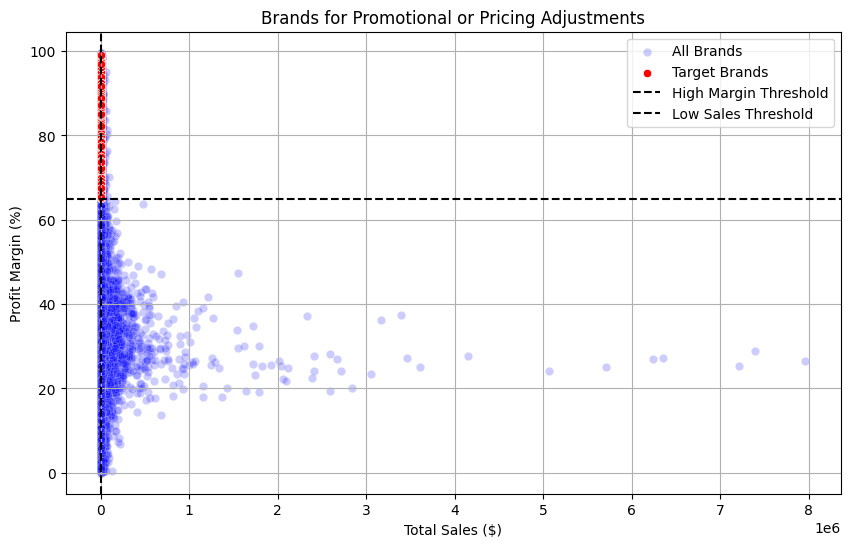

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")
plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold" )
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt. legend()
plt.grid (True)
plt.show()

**Which vendor and brands demonstrate the highest sales performance?**

In [59]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby ("VendorName") ["TotalSalesDollars"].sum().nlargest (10)
top_brands = df.groupby("Description") ["TotalSalesDollars"].sum().nlargest (10)
top_vendors

,TotalSalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,6.799010e+07
MARTIGNETTI COMPANIES,3.933036e+07
PERNOD RICARD USA,3.206320e+07
JIM BEAM BRANDS COMPANY,3.142302e+07
BACARDI USA INC,2.485482e+07
CONSTELLATION BRANDS INC,2.421875e+07
E & J GALLO WINERY,1.839990e+07
BROWN-FORMAN CORP,1.824723e+07
ULTRA BEVERAGE COMPANY LLP,1.650254e+07


In [60]:
top_brands

,TotalSalesDollars
Description,
Jack Daniels No 7 Black,7964746.76
Tito's Handmade Vodka,7399657.58
Grey Goose Vodka,7209608.06
Capt Morgan Spiced Rum,6356320.62
Absolut 80 Proof,6244752.03
Jameson Irish Whiskey,5715759.69
Ketel One Vodka,5070083.56
Baileys Irish Cream,4150122.07
Kahlua,3604858.66


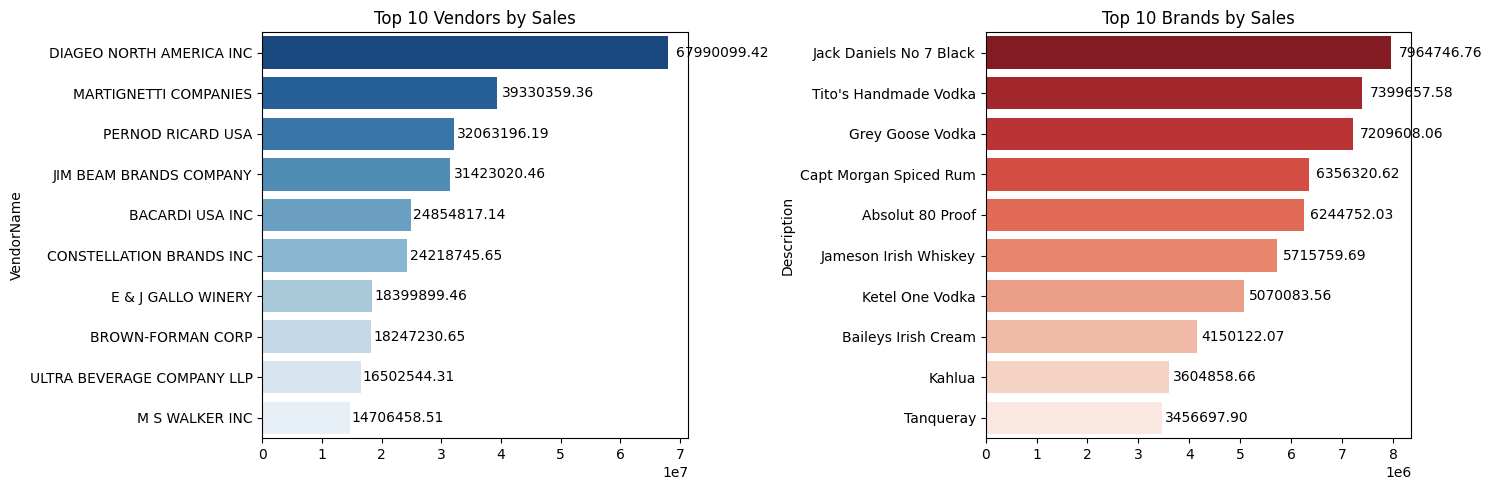

In [63]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
  ax1.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            s=f'{bar.get_width():.2f}',
            ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
  ax2.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            s=f'{bar.get_width():.2f}',
            ha='left', va='center' , fontsize=10, color='black')
plt.tight_layout()
plt.show()

**Which vendor contribute the most to the total purchased dollars?**

In [65]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [102]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()*100

In [103]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [104]:
#top 10 vendors
top_vendors = vendor_performance.head(10)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67
20,CONSTELLATION BRANDS INC,15273708.08,8945037.57,24218745.65,4.97
11,BROWN-FORMAN CORP,13238939.18,5008291.47,18247230.65,4.31
30,E & J GALLO WINERY,12068539.22,6331360.24,18399899.46,3.93
106,ULTRA BEVERAGE COMPANY LLP,11167081.61,5335462.70,16502544.31,3.63
53,M S WALKER INC,9764312.60,4942145.91,14706458.51,3.18


In [105]:
top_vendors.sum()

,0
VendorName,DIAGEO NORTH AMERICA INCMARTIGNETTI COMPANIESP...
TotalPurchaseDollars,201889391.43
GrossProfit,85846979.72
TotalSalesDollars,287736371.15
PurchaseContribution%,65.69


In [106]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30,16.30
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30,24.60
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64,40.00
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67,45.67
20,CONSTELLATION BRANDS INC,15273708.08,8945037.57,24218745.65,4.97,50.64
11,BROWN-FORMAN CORP,13238939.18,5008291.47,18247230.65,4.31,54.95
30,E & J GALLO WINERY,12068539.22,6331360.24,18399899.46,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11167081.61,5335462.70,16502544.31,3.63,62.51
53,M S WALKER INC,9764312.60,4942145.91,14706458.51,3.18,65.69


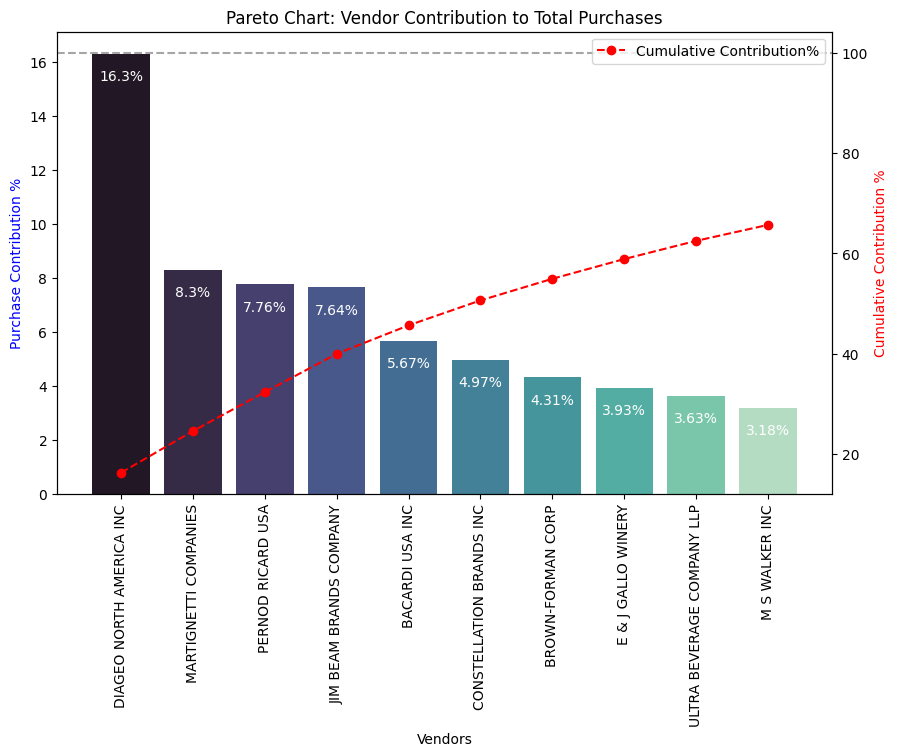

In [107]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors ['PurchaseContribution%']):
  ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed' , label='Cumulative Contribution%')

ax1.set_xticklabels(top_vendors ['VendorName'], rotation=90)
ax1.set_ylabel( 'Purchase Contribution %', color='blue')
ax2.set_ylabel( 'Cumulative Contribution %', color='red' )
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend (loc='upper right')

plt.show()

**How much of total procurement is dependent on the top vendors?**

In [110]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.69 %


Text(0.5, 1.0, "Top 10 Vendor's Purchase Contribution (%)")

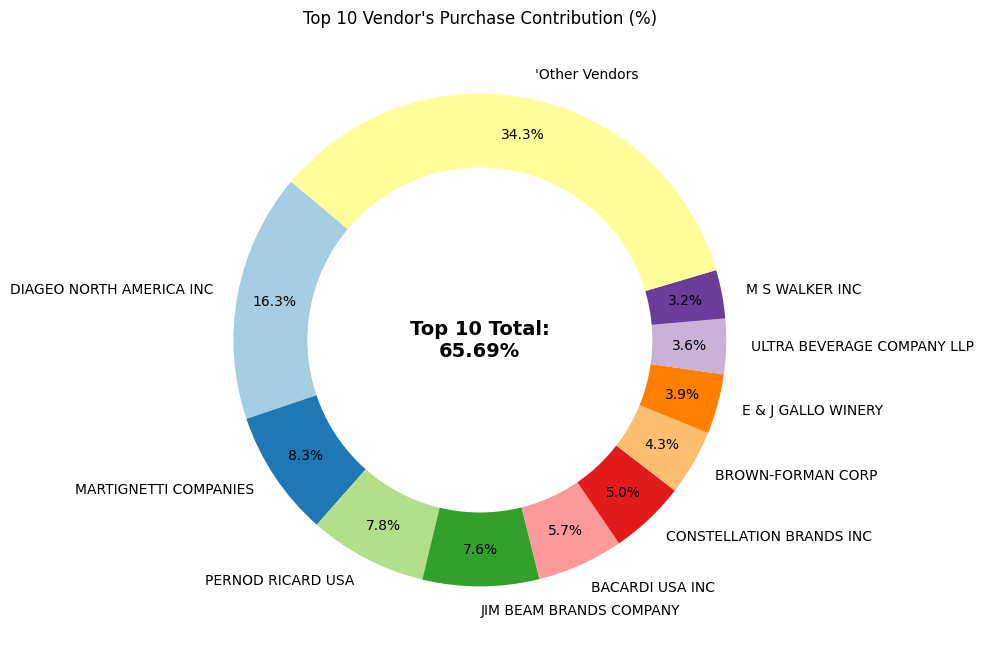

In [113]:
vendors = list(top_vendors ['VendorName' ]. values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append ("'Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")

**Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?**

In [114]:
df ['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [115]:
df ["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [116]:
df['OrderSize']

,OrderSize
0,Large
1,Large
2,Large
3,Large
4,Large
...,...
8560,Small
8561,Small
8562,Small
8563,Small


In [117]:
df.groupby('OrderSize')['UnitPurchasePrice'].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


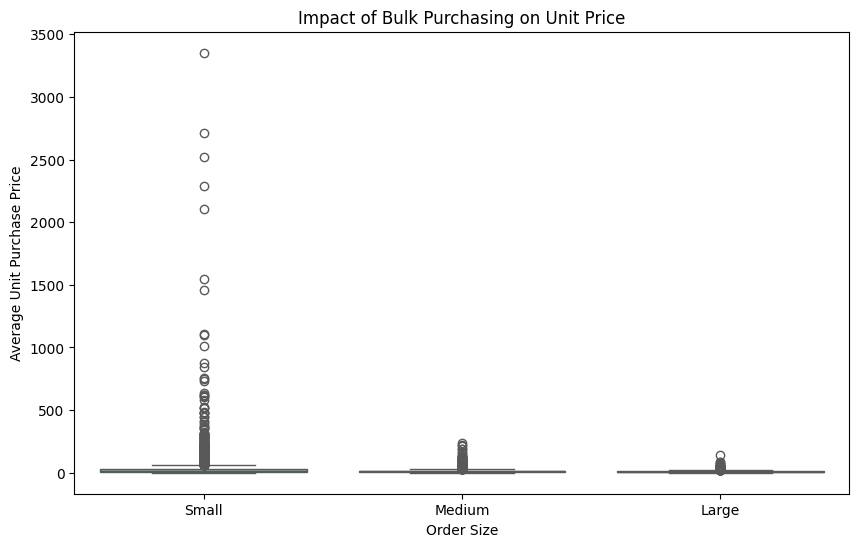

In [118]:
plt.figure(figsize=(10, 6))
sns. boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt. show()

**Which vendors have low inventory turnover, indicating excess stock and slow-moving products?**

In [122]:
df[df['StockTurnover']<1].groupby('VendorName')['StockTurnover'].mean().sort_values(ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


**How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?**

In [126]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', df["UnsoldInventoryValue"].sum())

Total Unsold Capital: 2708246.4999999995


In [128]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby ("VendorName") ["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue']
inventory_value_per_vendor.head (10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722209.05
46,JIM BEAM BRANDS COMPANY,554665.63
68,PERNOD RICARD USA,470625.61
116,WILLIAM GRANT & SONS INC,401960.83
30,E & J GALLO WINERY,228282.61
79,SAZERAC CO INC,198436.41
11,BROWN-FORMAN CORP,177733.74
20,CONSTELLATION BRANDS INC,133617.62
61,MOET HENNESSY USA INC,126477.70
77,REMY COINTREAU USA INC,118598.15


**What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.**

In [129]:
top_threshold = df ["TotalSalesDollars"]. quantile(0.75)
low_threshold = df ["TotalSalesDollars"] .quantile(0.25)

In [131]:
top_vendors = df[df ["TotalSalesDollars"]>= top_threshold]["ProfitMargin"].dropna()

low_vendors = df[df ["TotalSalesDollars"]<=low_threshold]["ProfitMargin"].dropna()

top_vendors

,ProfitMargin
0,25.297693
1,21.062810
2,24.675786
3,27.139908
4,28.412764
...,...
3523,79.684817
3681,85.782102
4751,93.085860
4920,95.012530


In [132]:
low_vendors

,ProfitMargin
5631,4.111764
5652,6.145626
5701,12.007271
5704,1.677308
5724,7.239599
...,...
8560,83.448276
8561,96.436186
8562,25.252525
8563,98.974037


In [133]:
def confidence_interval(data, confidence=0.95):
  mean_val = np.mean (data)
  std_err = np.std(data, ddof=1) / np.sqrt(len(data) ) # Standard error
  t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
  margin_of_error = t_critical * std_err
  return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61, Mean:  31.17
Low Vendors 95% CI: ( 40.48,  42.62), Mean:  41.55


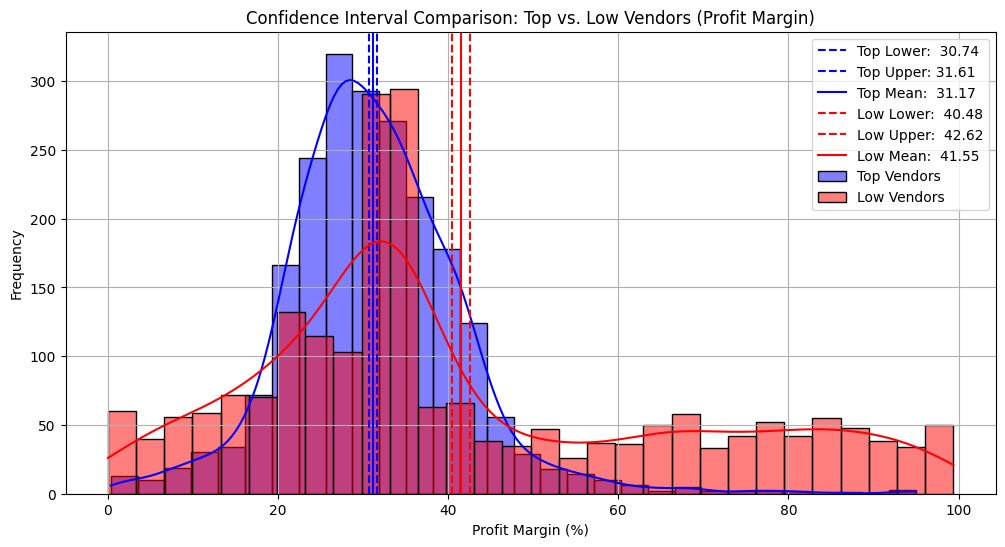

In [135]:
top_mean, top_lower, top_upper = confidence_interval (top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}, Mean: {top_mean: .2f}")
print(f"Low Vendors 95% CI: ({low_lower: .2f}, {low_upper: .2f}), Mean: {low_mean: .2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower: .2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean: .2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower: .2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper: .2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean: .2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend ()
plt.grid (True)
plt.show()

* The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
* For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
* For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

**Is there a significant difference in profit margins between top-performing and low-performing vendors?**

Hypothesis:

Ho (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [137]:
top_threshold = df ["TotalSalesDollars"] .quantile(0.75)
low_threshold = df ["TotalSalesDollars"]. quantile(0.25)

top_vendors = df [df ["TotalSalesDollars"] >= top_threshold] ["ProfitMargin"].dropna()
low_vendors = df [df ["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"] .dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
  print("Reject H0: There is a significant difference in profit margins between top and low-performing vendors.")
else:
  print("Fail to Reject Ho: No significant difference in profit margins.")

T-Statistic: -17.6440, P-Value: 0.0000
Reject H0: There is a significant difference in profit margins between top and low-performing vendors.
